In [ ]:
!pip install ultralytics roboflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import torch
print("Torch version:", torch.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch version: 2.10.0+cpu


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="S7YTCRIDwZlZmCLoDmbc")
project = rf.workspace("ahmad-younis-s-workspace").project("facade-cracks")
version = project.version(3)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Facade-Cracks-3 in yolov8:: 100%|██████████| 386/386 [00:00<00:00, 4459.37it/s]


In [ ]:
model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Facade-Cracks-3/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 751.7±343.8 MB/s, size: 28.2 KB)
val: Scanning /content/Facade-Cracks-3/valid/labels.cache... 39 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 10.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.4s/it 10.3s
                   all         39         43      0.727       0.86      0.825      0.528
Speed: 2.6ms preprocess, 243.0ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79409cc96a50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'P

In [ ]:
model.predict(
    source=f"{dataset.location}/valid/images",
    save=True
)


image 1/39 /content/Facade-Cracks-3/valid/images/IMG_20230922_174244_jpg.rf.82868eb7877afad163428a4c4b8c276f.jpg: 640x640 3 cracks, 212.3ms
image 2/39 /content/Facade-Cracks-3/valid/images/IMG_20230924_103522_jpg.rf.c080e02f8543c55297558aa083f757d0.jpg: 640x640 1 crack, 199.9ms
image 3/39 /content/Facade-Cracks-3/valid/images/IMG_20230924_1035354-20-_jpg.rf.4347f789554a6a0e01cc1eb8c89b2bab.jpg: 640x640 3 cracks, 196.1ms
image 4/39 /content/Facade-Cracks-3/valid/images/IMG_20230924_1035354-43-_jpg.rf.1c8051e239feac2690794c6925511484.jpg: 640x640 1 crack, 219.1ms
image 5/39 /content/Facade-Cracks-3/valid/images/IMG_20230924_1035354-44-_jpg.rf.f5e9a08c62b2931161e7032510d42c27.jpg: 640x640 2 cracks, 208.0ms
image 6/39 /content/Facade-Cracks-3/valid/images/IMG_20230924_1035354-48-_jpg.rf.8abd158950c765022ddfa5a21d46fe5c.jpg: 640x640 3 cracks, 206.4ms
image 7/39 /content/Facade-Cracks-3/valid/images/IMG_20230924_1035354-52-_jpg.rf.69e5194040386a13c2f2d5c5c87eedbd.jpg: 640x640 4 cracks, 210.

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crack'}
 obb: None
 orig_img: array([[[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 4,  4,  4],
         [13, 13, 13]],
 
        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 4,  4,  4],
         [ 0,  0,  0],
         [ 9,  9,  9]],
 
        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [10, 10, 10],
         [ 7,  7,  7],
         [19, 19, 19]],
 
        ...,
 
        [[15, 15, 15],
         [30, 30, 30],
         [16, 16, 16],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [17, 17, 17]],
 
        [[ 0,  0,  0],
         [ 0,  0,  0],
         [12, 12, 12],
         ...,
         [ 7,  7,  7],
         [17, 17, 17],
         [ 0,  0,  0]],
 
        [[14, 14, 14],
     

In [ ]:
import os
os.listdir("runs/detect")

['val', 'predict', 'train']

In [ ]:
os.listdir("runs/detect/train")  # change train -> train2 if needed

['confusion_matrix_normalized.png',
 'train_batch0.jpg',
 'BoxR_curve.png',
 'train_batch2.jpg',
 'val_batch0_pred.jpg',
 'weights',
 'train_batch320.jpg',
 'labels.jpg',
 'BoxP_curve.png',
 'val_batch1_pred.jpg',
 'train_batch1.jpg',
 'BoxF1_curve.png',
 'results.csv',
 'train_batch322.jpg',
 'confusion_matrix.png',
 'val_batch1_labels.jpg',
 'val_batch0_labels.jpg',
 'train_batch321.jpg',
 'results.png',
 'BoxPR_curve.png',
 'args.yaml']

In [ ]:
import os

print("Available detect folders:")
print(os.listdir("runs/detect"))

Available detect folders:
['val', 'predict', 'train']


In [ ]:
print(os.listdir("runs/detect/train"))

['confusion_matrix_normalized.png', 'train_batch0.jpg', 'BoxR_curve.png', 'train_batch2.jpg', 'val_batch0_pred.jpg', 'weights', 'train_batch320.jpg', 'labels.jpg', 'BoxP_curve.png', 'val_batch1_pred.jpg', 'train_batch1.jpg', 'BoxF1_curve.png', 'results.csv', 'train_batch322.jpg', 'confusion_matrix.png', 'val_batch1_labels.jpg', 'val_batch0_labels.jpg', 'train_batch321.jpg', 'results.png', 'BoxPR_curve.png', 'args.yaml']


#Evidence Collection

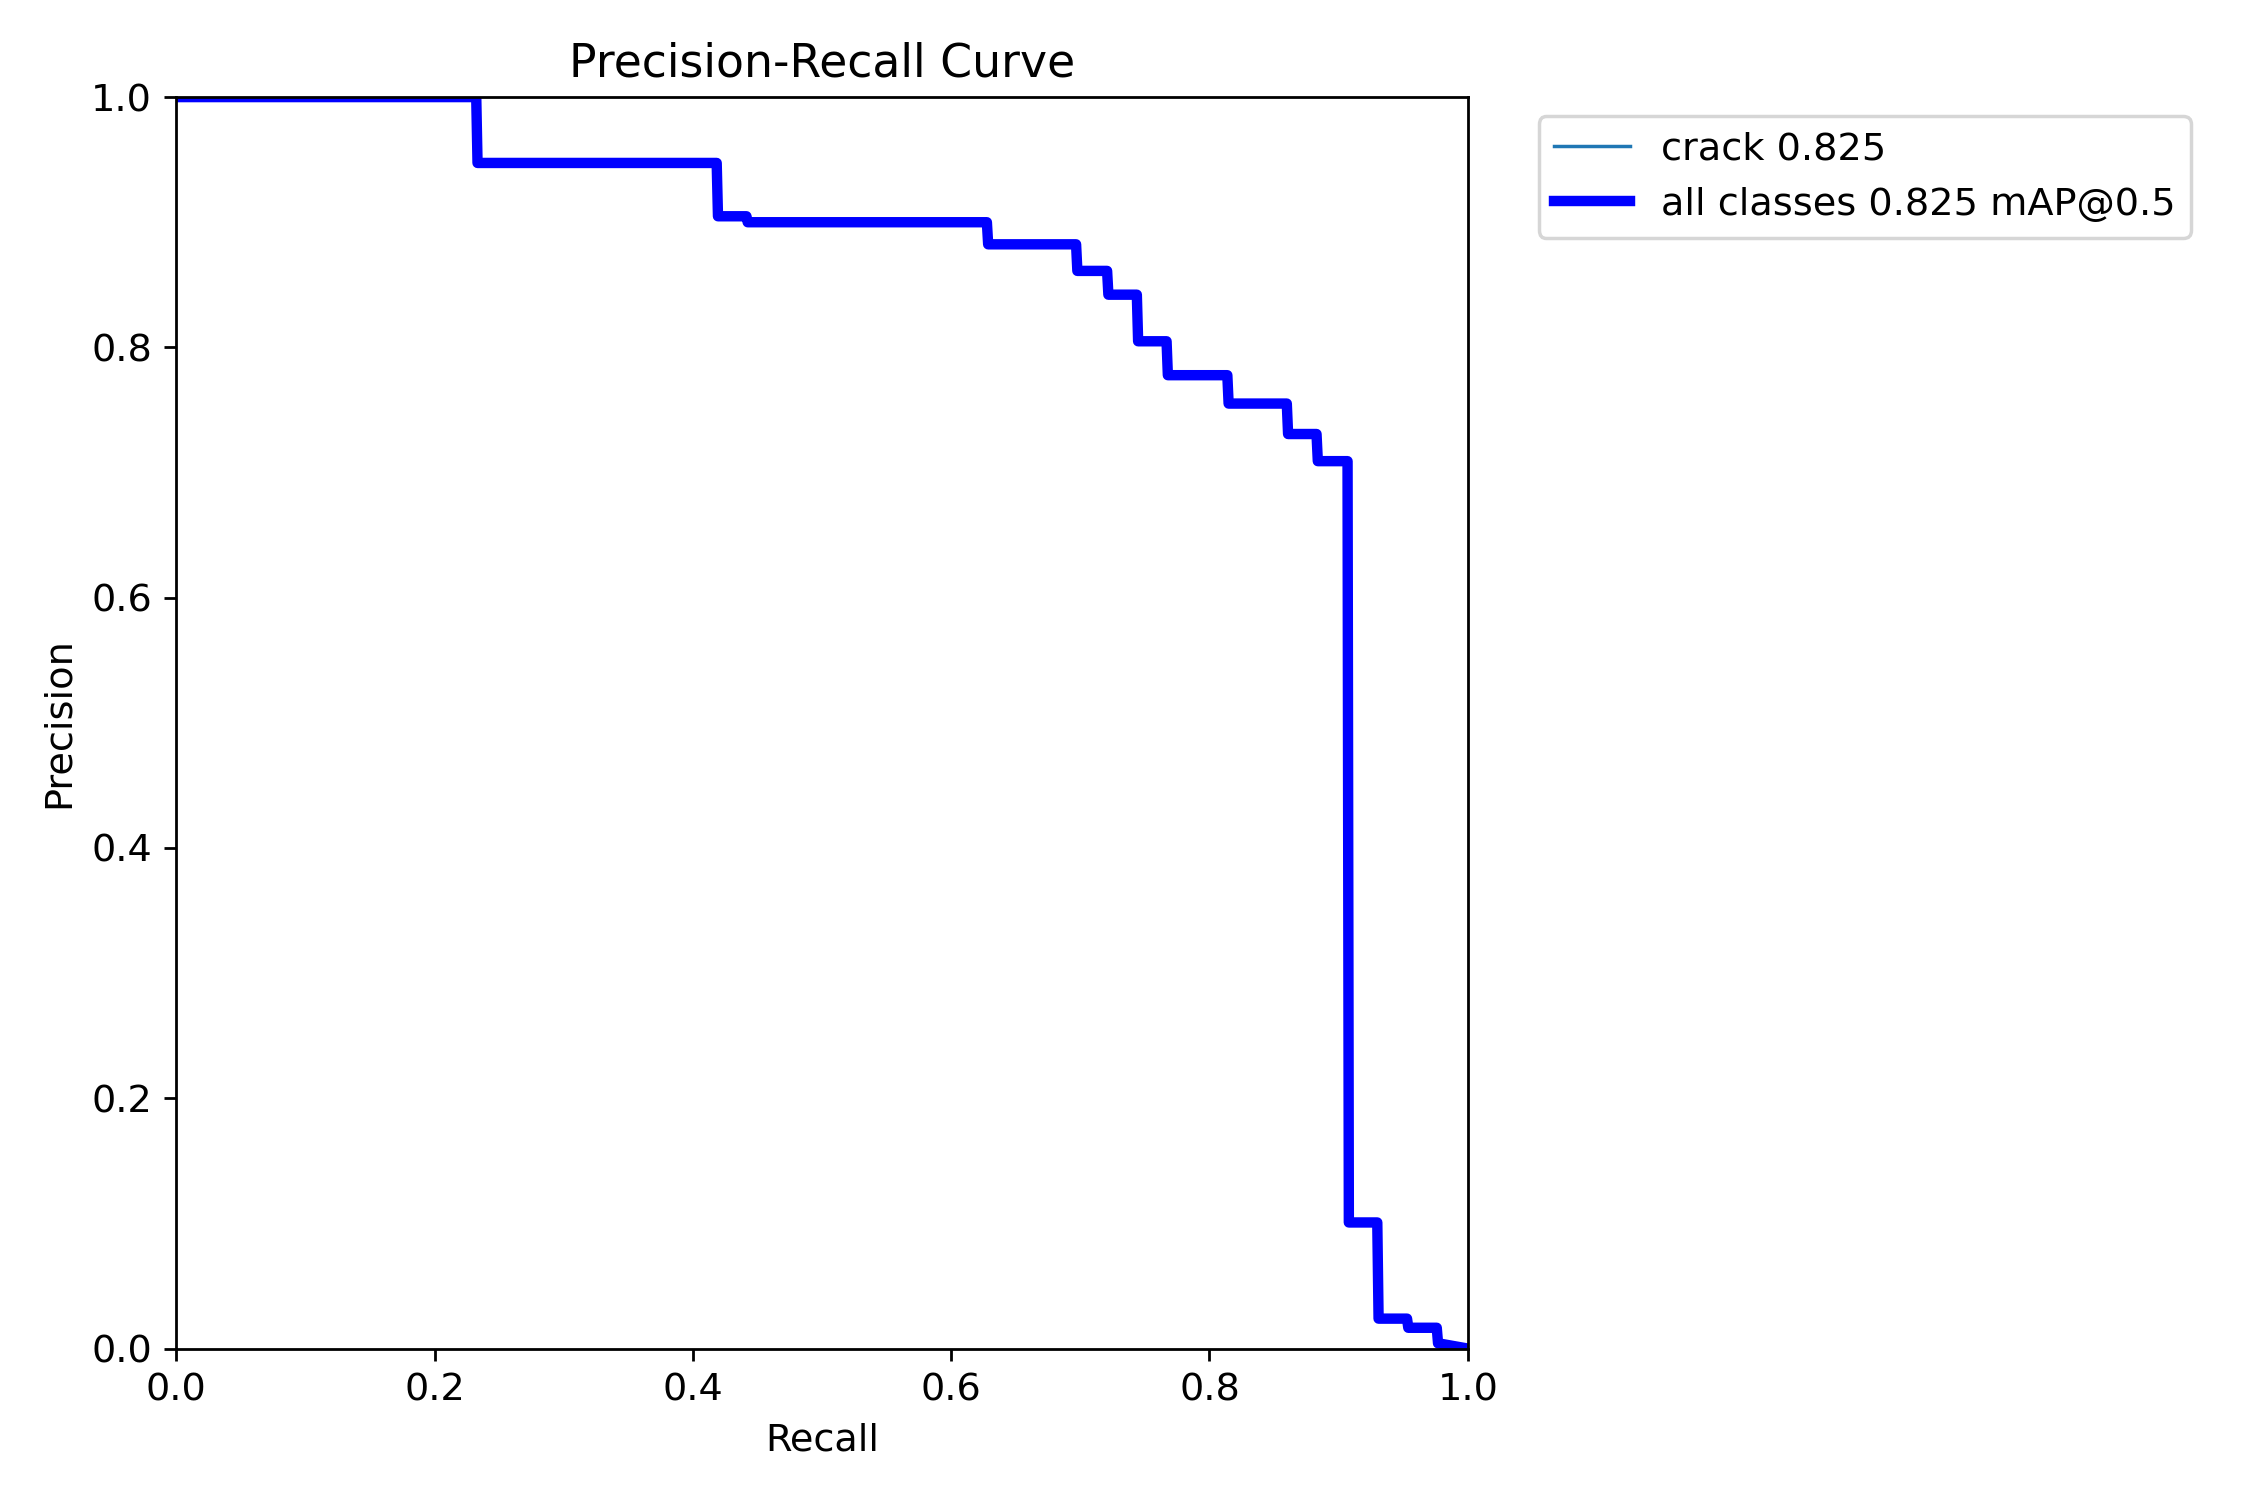

In [ ]:
from IPython.display import Image
Image("runs/detect/train/BoxPR_curve.png")

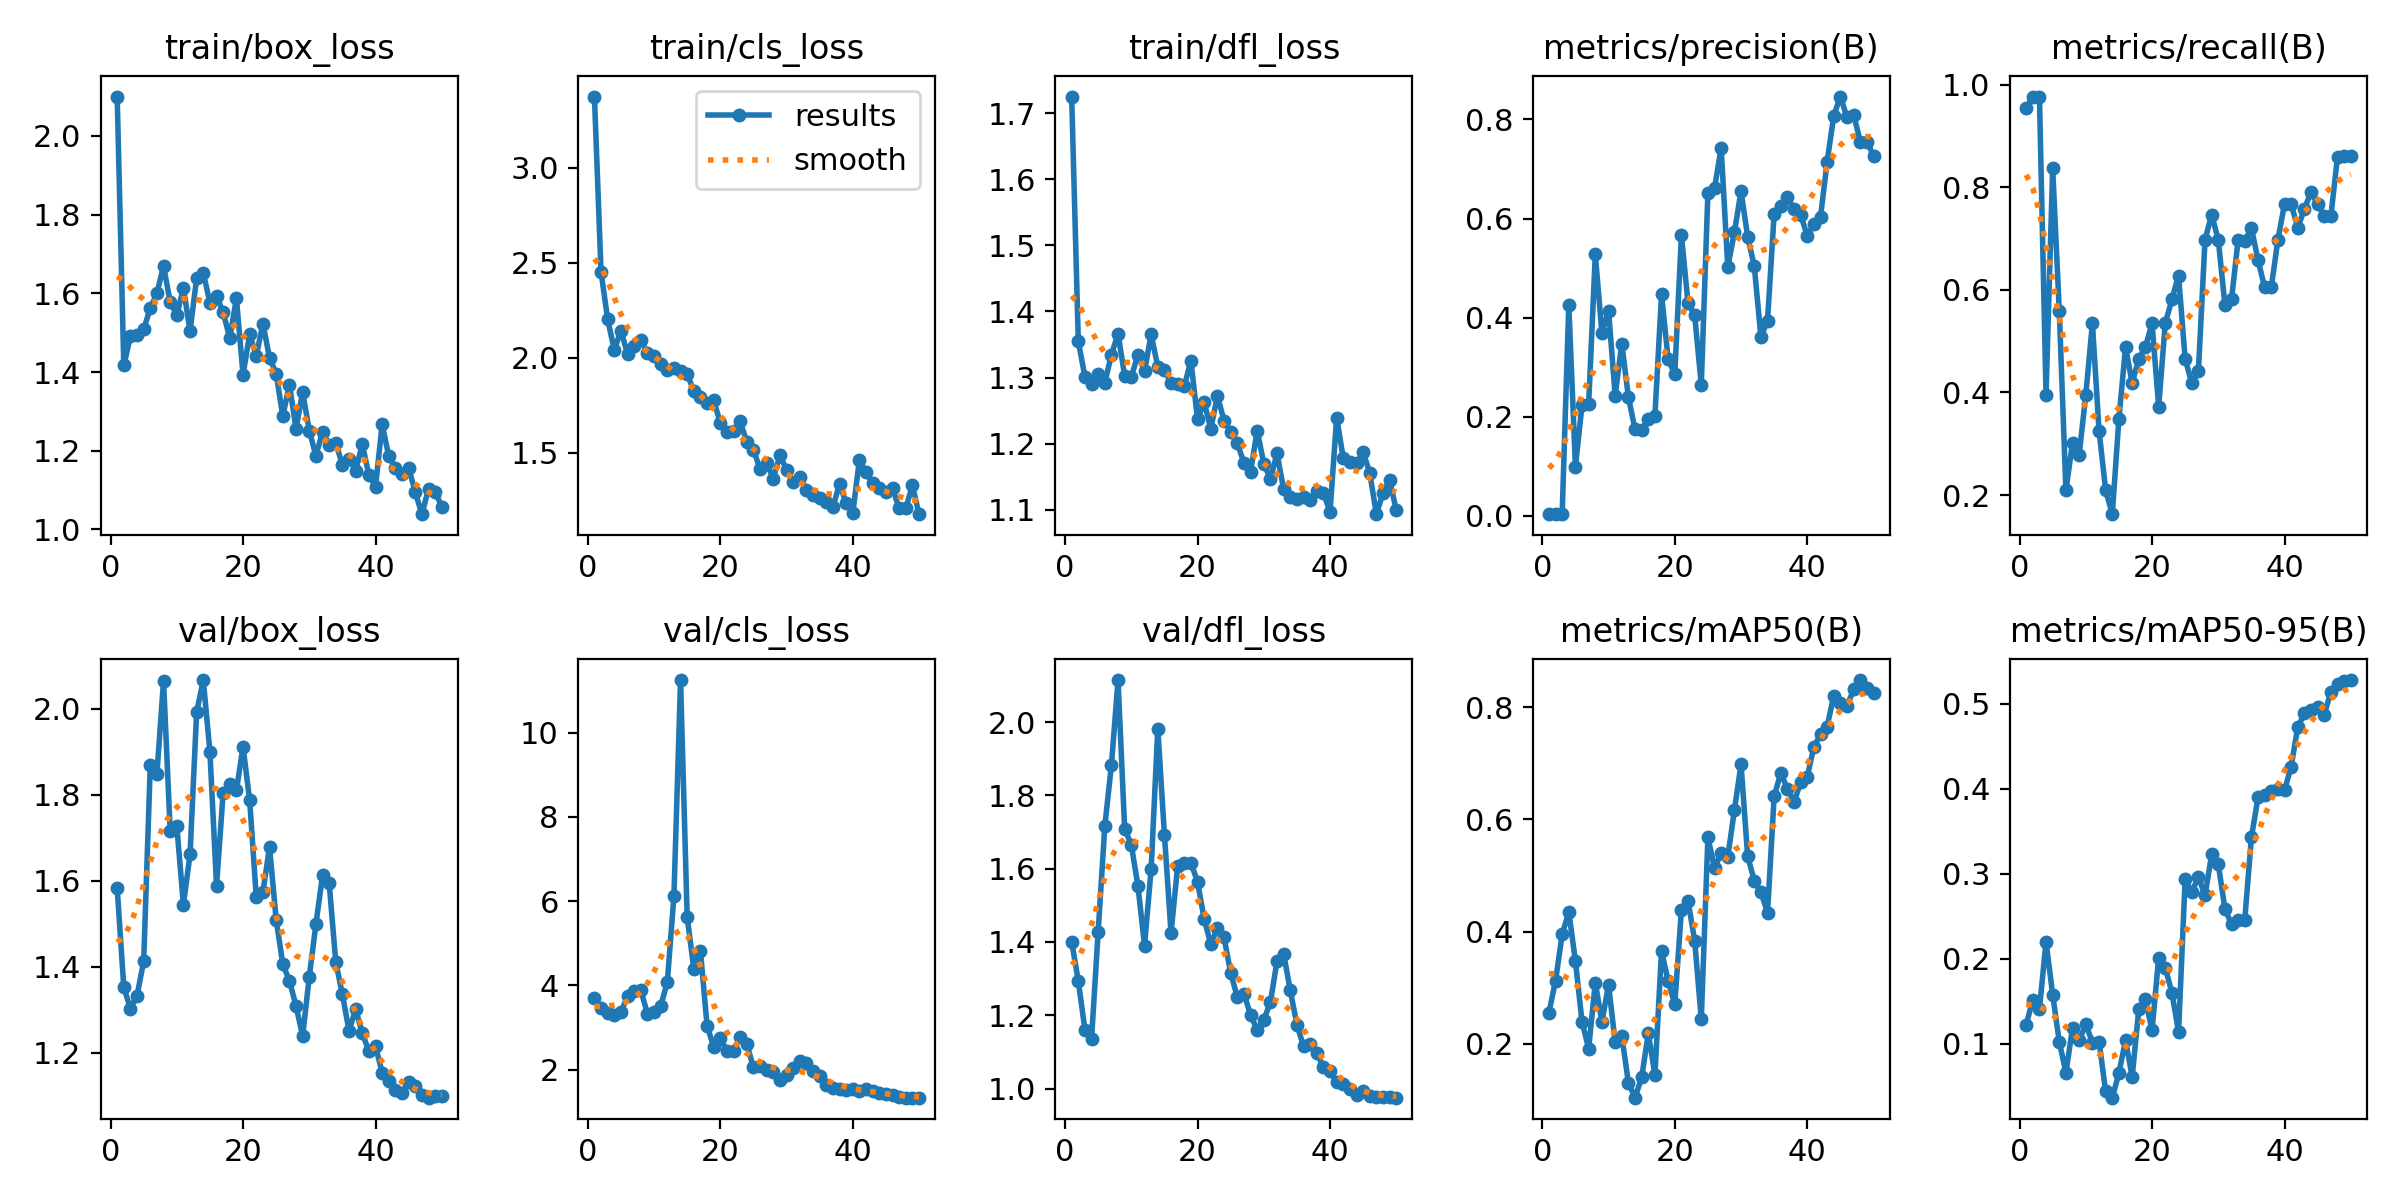

In [ ]:
from IPython.display import Image

Image("runs/detect/train/results.png")

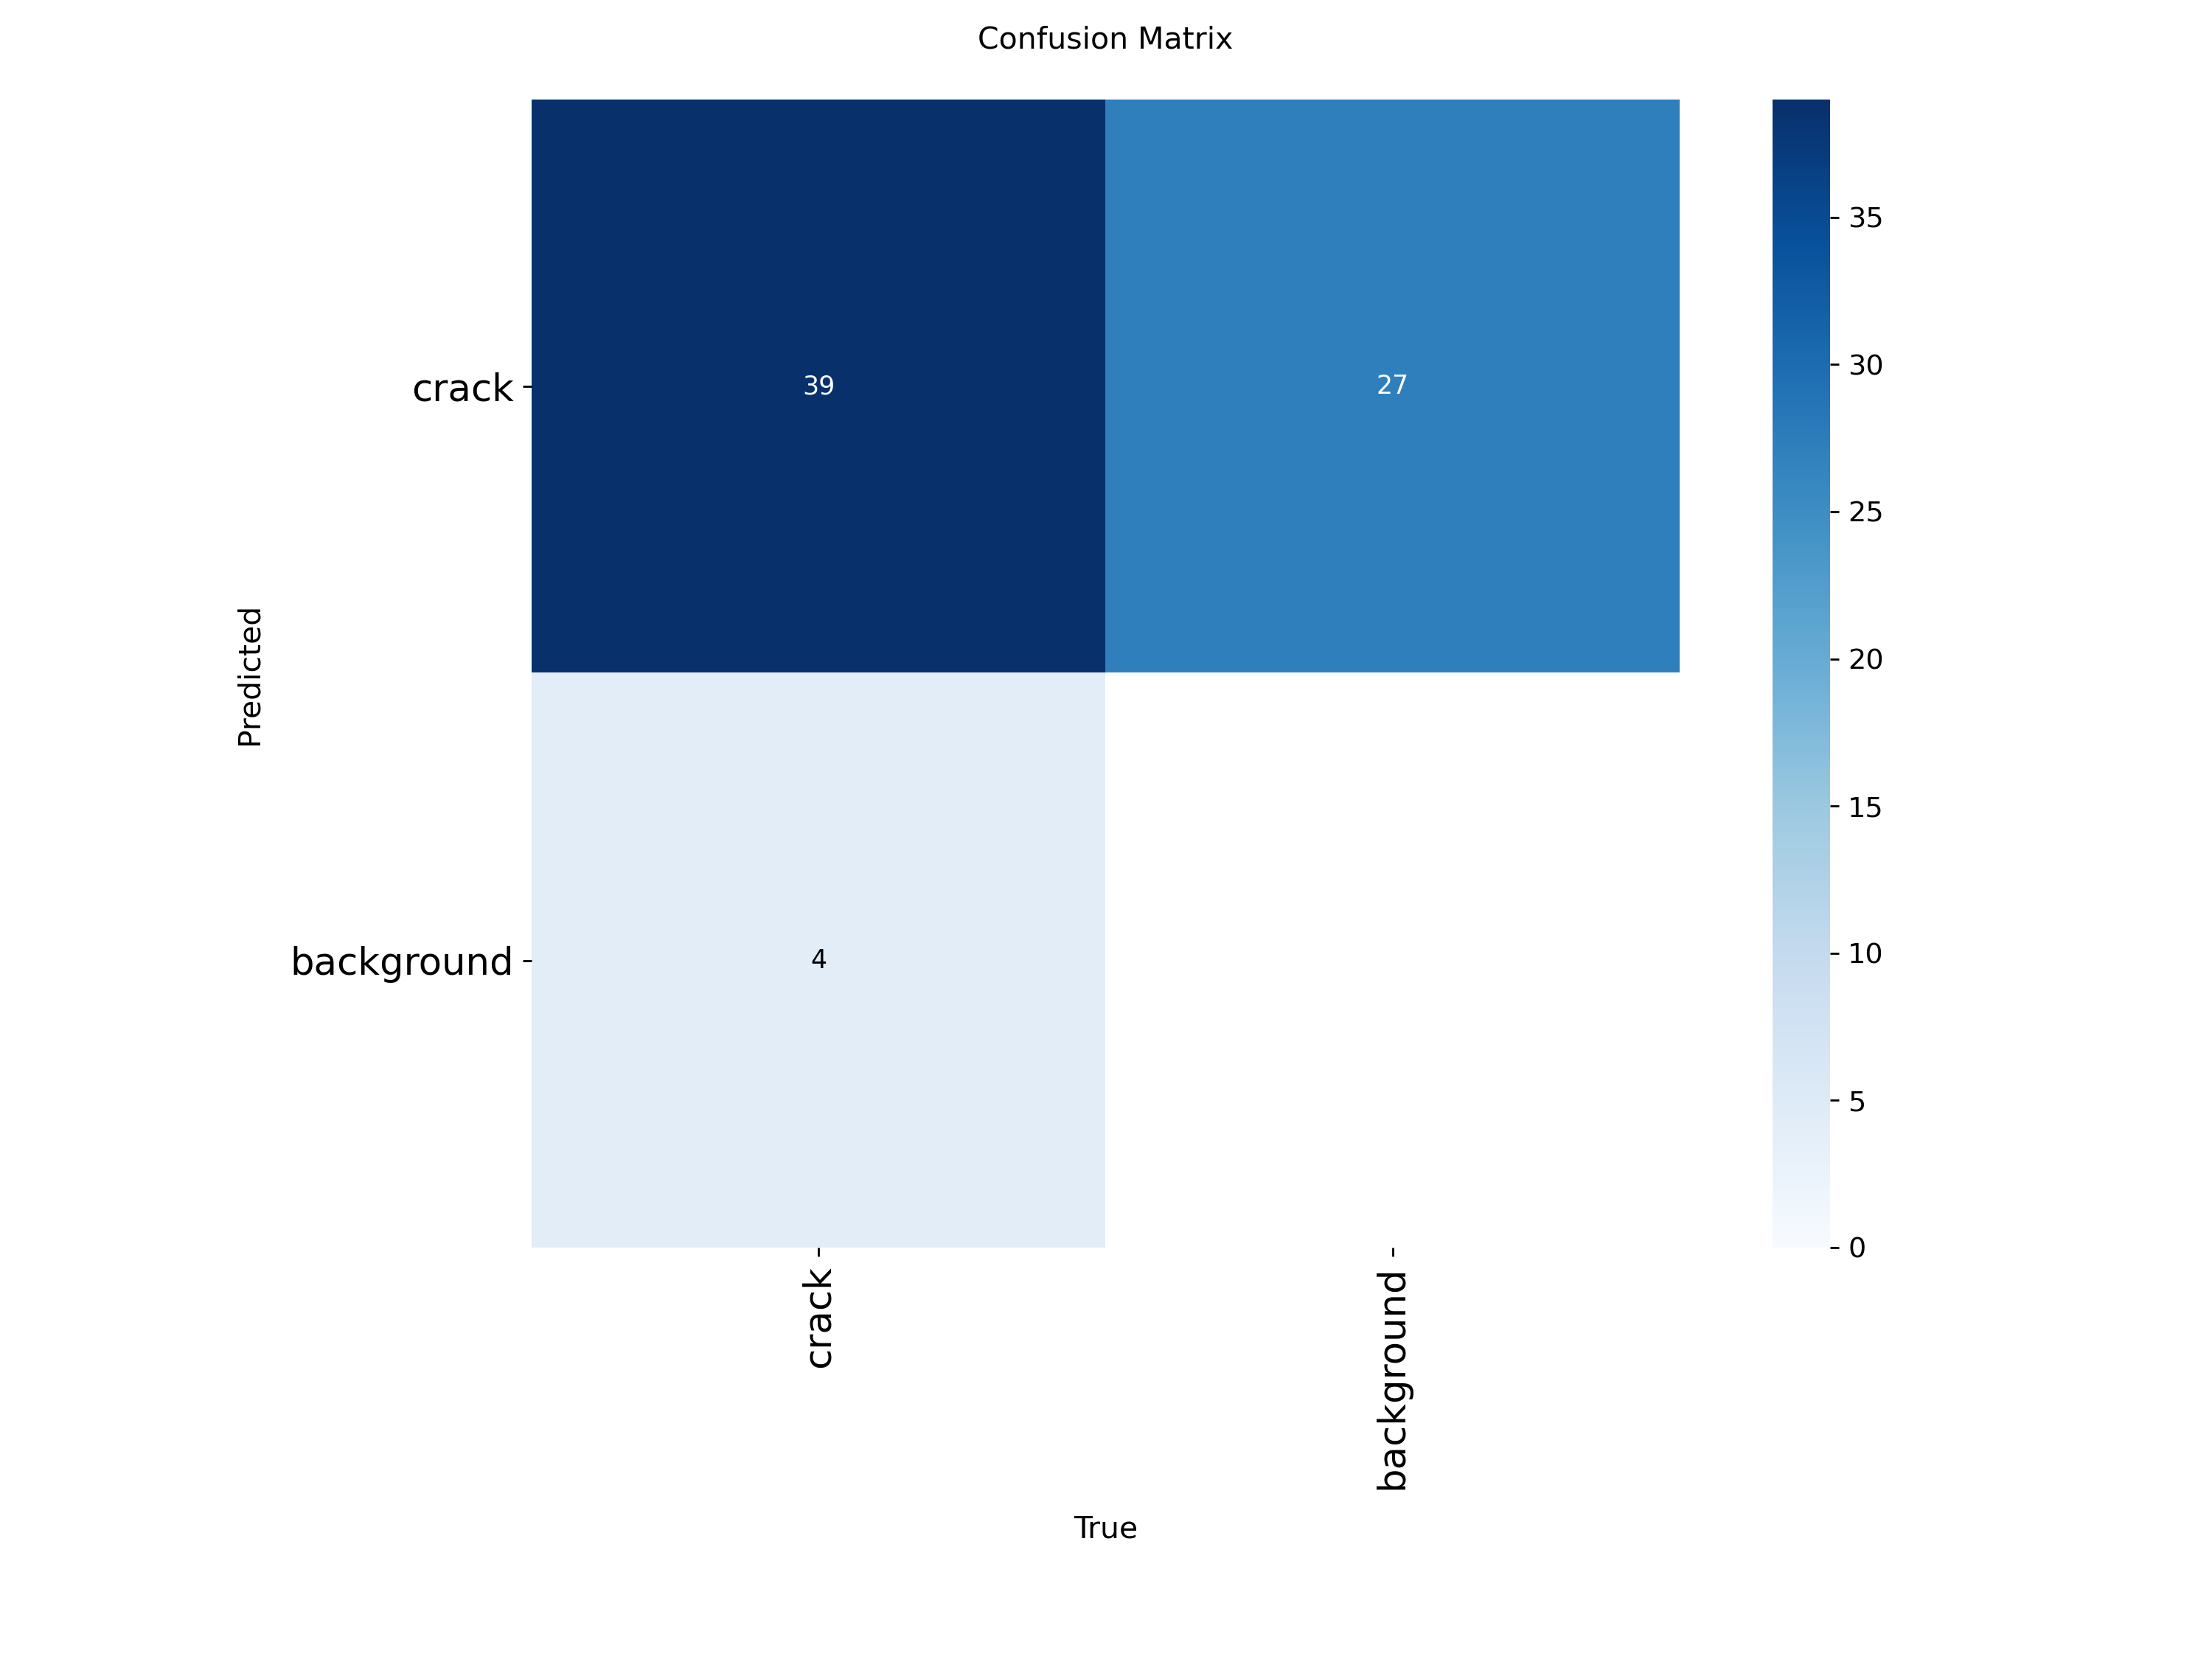

In [ ]:
from IPython.display import Image
Image("runs/detect/train/confusion_matrix.png")

#Validation Predictions

In [ ]:
model.val()

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 468.1±191.2 MB/s, size: 36.4 KB)
val: Scanning /content/Facade-Cracks-3/valid/labels.cache... 39 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 7.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.9s/it 11.6s
                   all         39         43      0.727       0.86      0.825      0.528
Speed: 12.6ms preprocess, 266.9ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79410247db80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
os.listdir("runs/detect/val")

['val_batch2_labels.jpg',
 'confusion_matrix_normalized.png',
 'BoxR_curve.png',
 'val_batch0_pred.jpg',
 'BoxP_curve.png',
 'val_batch1_pred.jpg',
 'BoxF1_curve.png',
 'val_batch2_pred.jpg',
 'confusion_matrix.png',
 'val_batch1_labels.jpg',
 'val_batch0_labels.jpg',
 'BoxPR_curve.png']

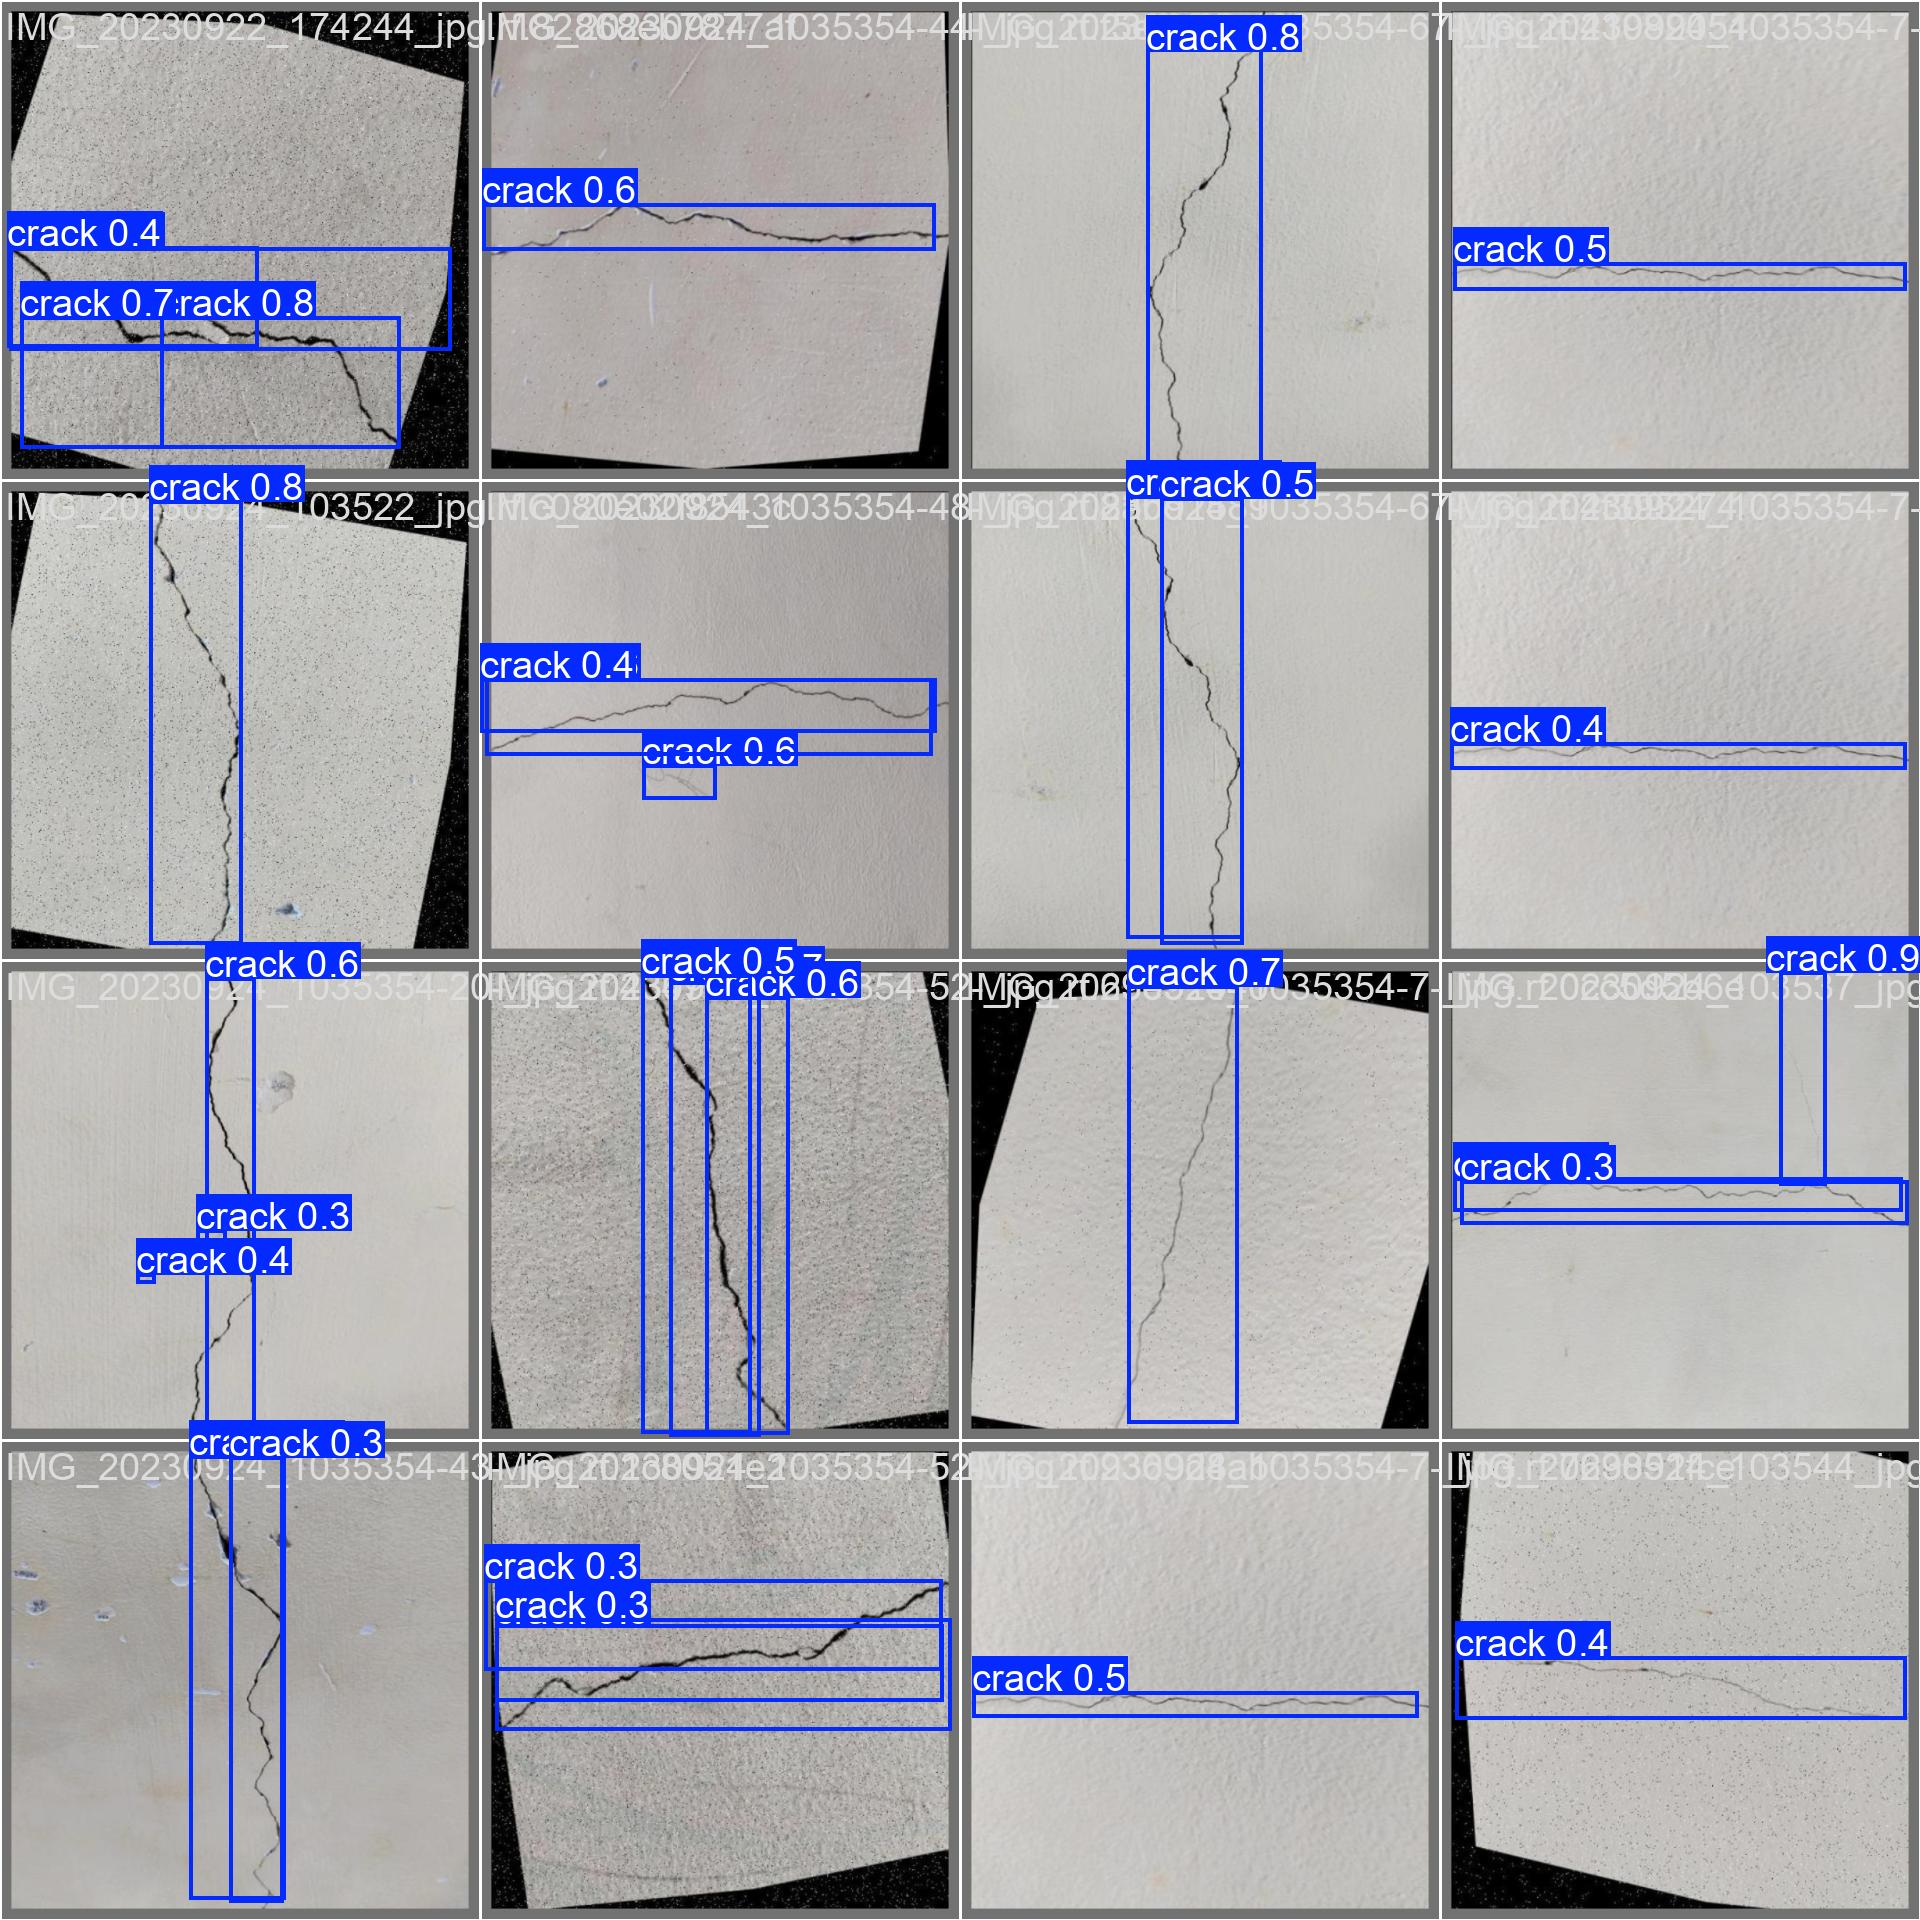

In [ ]:
Image("runs/detect/val/val_batch0_pred.jpg")


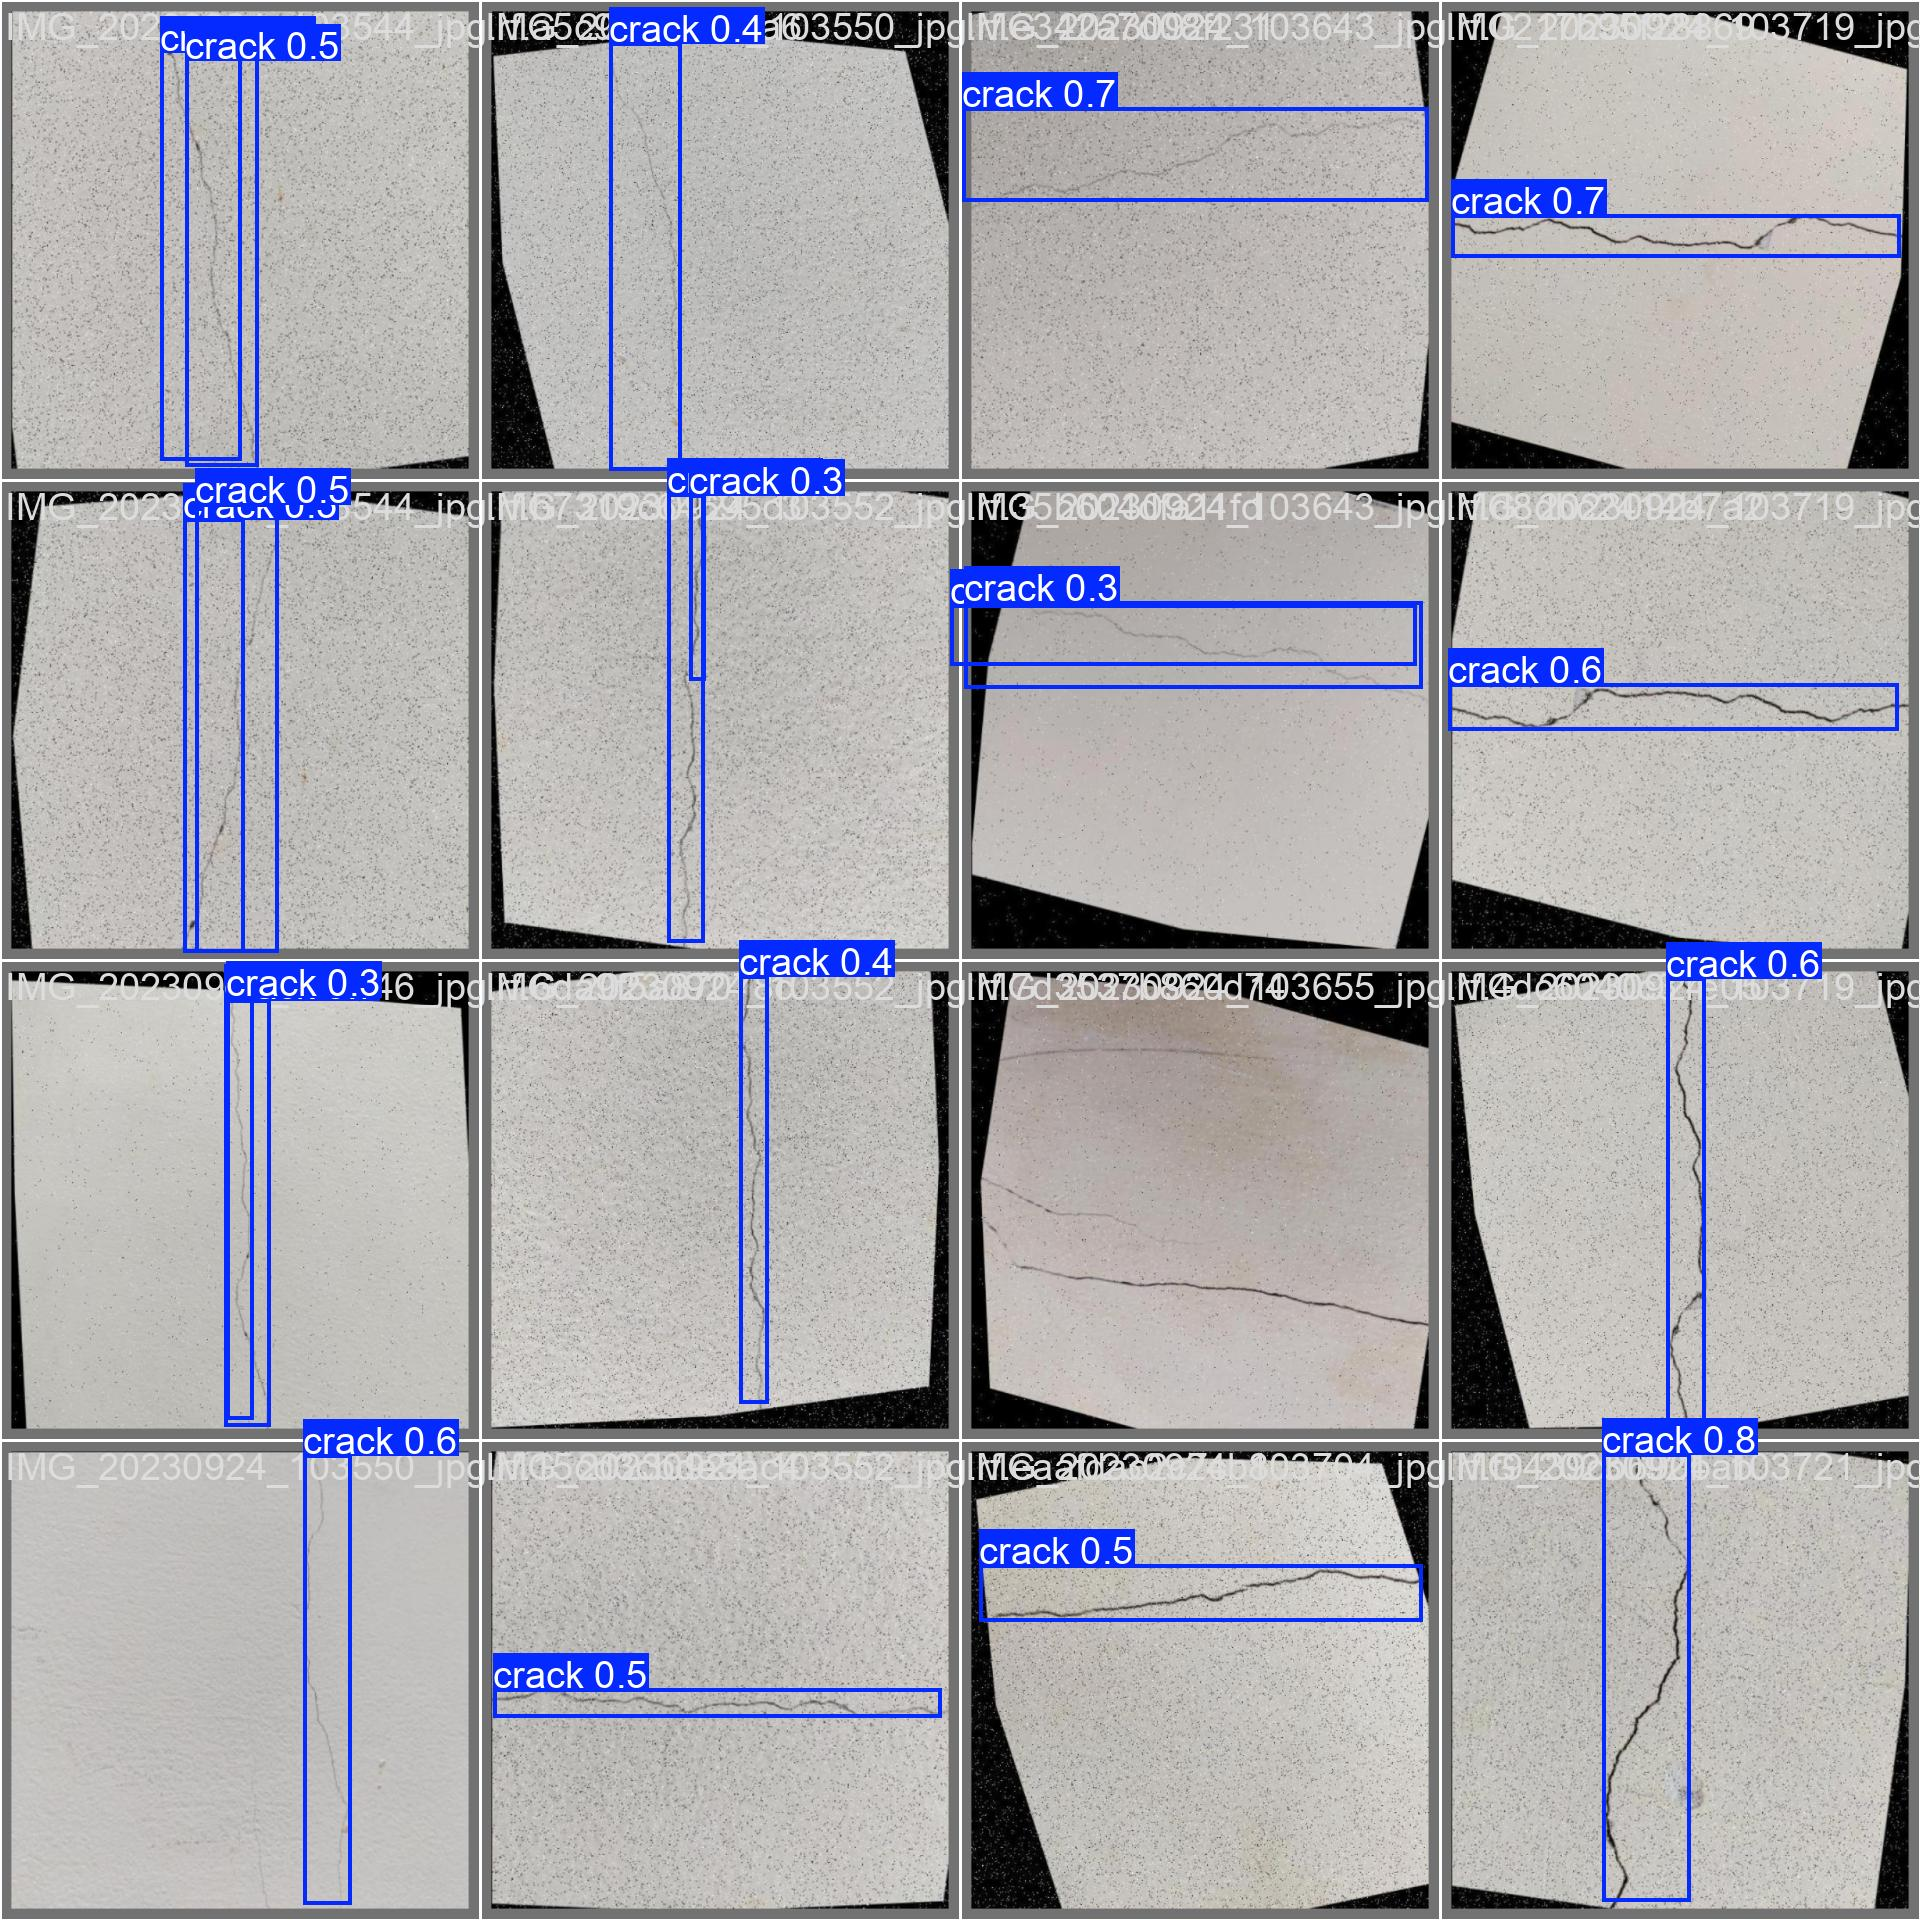

In [ ]:
Image("runs/detect/val/val_batch1_pred.jpg")

#Inference on New Images

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 0001.jpg to 0001.jpg
Saving 0002.jpg to 0002.jpg
Saving 0003.jpg to 0003.jpg
Saving 0004.jpg to 0004.jpg
Saving 0005.jpeg to 0005.jpeg


In [ ]:
model.predict(source="/content/", save=True)


image 1/5 /content/0001.jpg: 384x640 2 cracks, 156.8ms
image 2/5 /content/0002.jpg: 640x288 5 cracks, 111.8ms
image 3/5 /content/0003.jpg: 640x288 3 cracks, 110.7ms
image 4/5 /content/0004.jpg: 640x288 1 crack, 163.2ms
image 5/5 /content/0005.jpeg: 640x288 4 cracks, 152.9ms
Speed: 3.3ms preprocess, 139.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 288)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crack'}
 obb: None
 orig_img: array([[[187, 197, 204],
         [188, 198, 205],
         [182, 194, 200],
         ...,
         [170, 185, 188],
         [174, 186, 190],
         [174, 186, 190]],
 
        [[201, 211, 218],
         [207, 219, 225],
         [207, 219, 225],
         ...,
         [177, 192, 195],
         [175, 187, 191],
         [175, 187, 191]],
 
        [[185, 197, 203],
         [188, 200, 206],
         [180, 192, 198],
         ...,
         [177, 192, 195],
         [175, 187, 191],
         [175, 187, 191]],
 
        ...,
 
        [[153, 153, 153],
         [157, 159, 159],
         [148, 148, 148],
         ...,
         [137, 138, 136],
         [136, 134, 133],
         [136, 134, 133]],
 
        [[149, 151, 152],
         [153, 155, 156],
         [142, 144, 144],
         ...,
         [132, 132,

In [ ]:
os.listdir("runs/detect/predict")

['IMG_20230924_103546_jpg.rf.6da9f5a87078cb1a8edde0d955c7c4c8.jpg',
 'IMG_20230924_103723_jpg.rf.4d74f65eb8aa0fd0ec743f5e0a1107da.jpg',
 'IMG_20230924_1035354-43-_jpg.rf.1c8051e239feac2690794c6925511484.jpg',
 'IMG_20230924_103643_jpg.rf.0217b95f28869658bf84225178a604cb.jpg',
 '0003.jpg',
 'IMG_20230924_103537_jpg.rf.c3f5a150df2460c364d627cadce518a0.jpg',
 'IMG_20230924_104156_jpg.rf.256bfad760a22f087e768d8cb5cec091.jpg',
 'IMG_20230924_103544_jpg.rf.a5c98c8d820a6a53712c51471efac05e.jpg',
 'IMG_20230924_1035354-67-_jpg.rf.4f39527419d4ba059f34e1044af1b78d.jpg',
 '0001.jpg',
 '0002.jpg',
 'IMG_20230924_1035354-7-_jpg.rf.f3d62d0a28d493a50abb9ef92b414f24.jpg',
 'IMG_20230924_103552_jpg.rf.35b604dfa11fd45c09e820e73970538e.jpg',
 'IMG_20230924_103550_jpg.rf.15cd3cbde5ac40eda18a6b09004718b4.jpg',
 'IMG_20230924_103719_jpg.rf.dbd834e334588f58de0ca2594589f102.jpg',
 'IMG_20230924_104201_jpg.rf.3b91147cc36ba7c4c4e1e784bd6de326.jpg',
 'IMG_20230924_1035354-44-_jpg.rf.f5e9a08c62b2931161e7032510d42